<div style="width: 100%; overflow: hidden;">
    <div style="width: 150px; float: left;"> <img src="data/D4Sci_logo_ball.png" alt="Data For Science, Inc" align="left" border="0" width=150px> </div>
    <div style="float: left; margin-left: 10px;"> <h1>Epidemiology 304</h1>
<h1>Demographics</h1>
        <p>Bruno Gonçalves<br/>
        <a href="http://www.data4sci.com/">www.data4sci.com</a><br/>
            @bgoncalves, @data4sci</p></div>
</div>

In [1]:
from collections import Counter
from pprint import pprint

import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt 
from matplotlib.lines import Line2D

import sklearn
from sklearn.linear_model import LinearRegression

from ipywidgets import interact

import epidemik
from epidemik import EpiModel

import tqdm as tq
from tqdm.notebook import tqdm

import watermark

%load_ext watermark
%matplotlib inline

We start by printing out the versions of the libraries we're using for future reference

In [2]:
%watermark -n -v -m -g -iv

Python implementation: CPython
Python version       : 3.11.7
IPython version      : 8.12.3

Compiler    : Clang 14.0.6 
OS          : Darwin
Release     : 24.3.0
Machine     : arm64
Processor   : arm
CPU cores   : 16
Architecture: 64bit

Git hash: a3e44a3dcde157c72d6d80b7dd5db96a95391cbd

numpy     : 1.26.4
pandas    : 2.2.3
tqdm      : 4.66.4
watermark : 2.4.3
epidemik  : 0.1.3.3
sklearn   : 1.6.1
matplotlib: 3.8.0



Load default figure style

In [3]:
plt.style.use('d4sci.mplstyle')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Basic SIR model

We load the usual SIR model from the model library

In [4]:
SIR = EpiModel.download_model('SIR.yaml')
print(SIR)

# Epidemic Model with 3 compartments and 2 transitions:
Name: SIR

Parameters:
  beta : 0.2
  mu : 0.1


Transitions:
  - I -> R mu
  - S + I = I beta

# R0=2.00


And update the infection rate

In [5]:
SIR.params['beta'] = 0.3

In [6]:
print(SIR)

# Epidemic Model with 3 compartments and 2 transitions:
Name: SIR

Parameters:
  beta : 0.3
  mu : 0.1


Transitions:
  - I -> R mu
  - S + I = I beta

# R0=3.00


We set the inital conditions

In [7]:
N = 10_000
I0 = 1
R0 = 0
S0 = N - I0 - R0
tmax = 365

Integrate it

In [8]:
SIR.integrate(tmax, S=S0, I=I0, R=R0)

And visualize the results

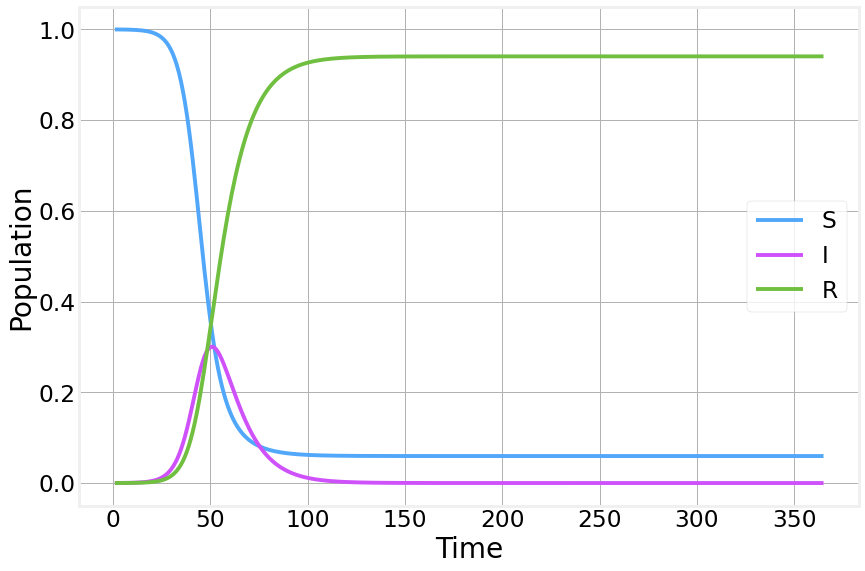

In [9]:
fig, ax = plt.subplots(1)
(SIR.S/N).plot(ax=ax) 
(SIR.I/N).plot(ax=ax)
(SIR.R/N).plot(ax=ax)
ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.legend()

# Demographics

Traditional models as the one above, keeps the total population constant

In [10]:
SIR.values_.sum(axis=1).describe()

count    3.650000e+02
mean     1.000000e+04
std      2.167828e-12
min      1.000000e+04
25%      1.000000e+04
50%      1.000000e+04
75%      1.000000e+04
max      1.000000e+04
dtype: float64

We can change this by including demographics (births and deaths) into the model. First we explore the demographics functionality in isolation by adding a birth rate:

In [11]:
simple = EpiModel()
simple.add_birth_rate('S', birth=0.1)

meaning a (unrealistic) $10\%$ growth per day. Integrating:

In [12]:
simple.integrate(160, S=N)

We can verify that it is correct by using a simple fit:

In [13]:
X = simple.values_.index.values.reshape(-1, 1)
# We take the log since we expect exponential growth
y = np.log(simple.values_.values)

lm  = LinearRegression()
lm.fit(X, y)

LinearRegression()

Recovering the expected value.

In [14]:
lm.coef_

array([[0.10003492]])

and visualizing. We can also add a death rate, which can by used to balance out the birth rate:

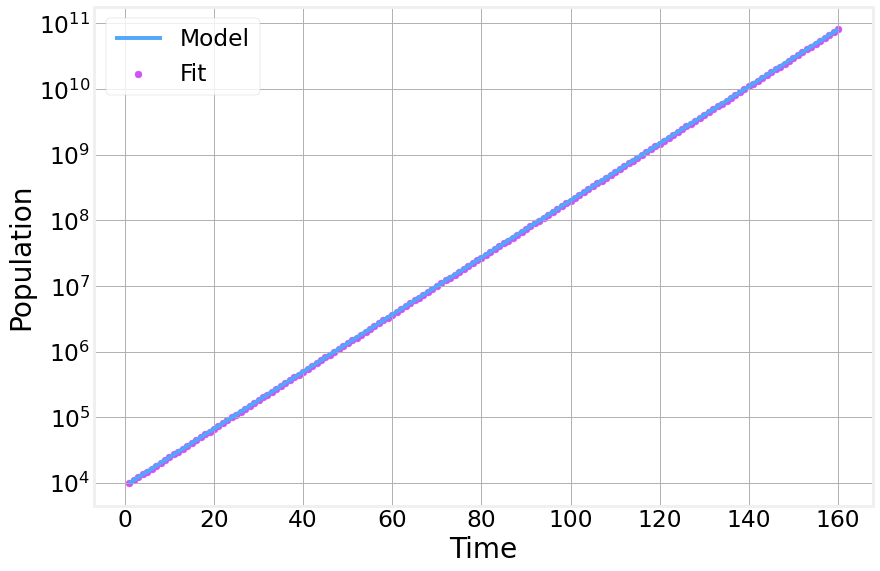

In [15]:
fig, ax = plt.subplots(1)
ax.set_yscale('log')
simple.S.plot(ax=ax)
ax.scatter(X, np.exp(lm.predict(X)), c=colors[1], zorder=-1, s=50)
ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.legend(['Model', 'Fit'])

In [16]:
simple.add_death_rate('S', death=0.1)

As a result, we expect that the population remains constant as before: 

In [17]:
simple.integrate(tmax, S=N)

Text(0, 0.5, 'Population')

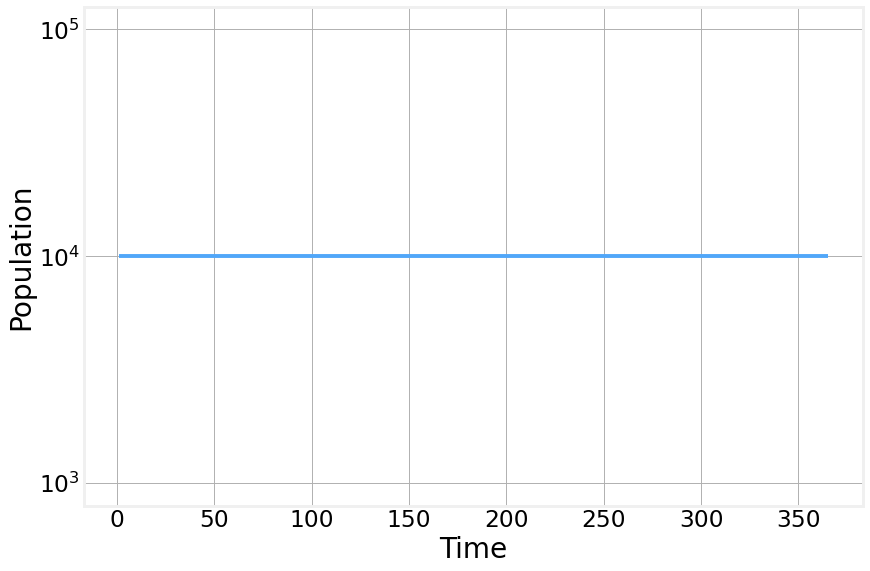

In [18]:
fig, ax = plt.subplots(1)
ax.set_yscale('log')
simple.S.plot(ax=ax)
ax.set_xlabel('Time')
ax.set_ylabel('Population')

# Fixed Numbers

An alternative to a specific birth/death rate is to just have a fixed number of individuals being born at any given day. This could be a simple way to integrate the effect of case importation, for example:

In [19]:
fixed = EpiModel()

new_individuals = 100

fixed.add_birth_rate('S', rate=new_individuals, fixed=True)

In [20]:
fixed.integrate(160, S=N)

As expected the population increases in a pre defined maner.

In [21]:
fixed.values_

,S
1,10000.0
2,10100.0
3,10200.0
4,10300.0
5,10400.0
...,...
156,25500.0
157,25600.0
158,25700.0
159,25800.0


# SIR with demographics

Now we build out our full SIR model with demographics. For simplicity, we set the birth and death rates to be the same

In [22]:
gamma = 0.01 # 1% turnover per day (!)

SIR_demo = EpiModel()
SIR_demo.add_interaction('S','I', 'I', beta=0.3)
SIR_demo.add_spontaneous('I', 'R', mu=0.1)

# Newborns start out in the S compartment
SIR_demo.add_birth_rate('S', birth=gamma)
# Death rate is the same for every compartment
SIR_demo.add_death_rate(death=gamma)

In [23]:
print(SIR_demo)

# Epidemic Model with 3 compartments and 2 transitions:

Parameters:
  beta : 0.3
  mu : 0.1
  birth : 0.01
  death : 0.01


Transitions:
  - I -> R death
  - S + I = I beta


Demographics:
  - I ->: death # death rate
  - -> S: birth # birth rate
  - S ->: death # death rate
  - R ->: death # death rate

# R0=3.00


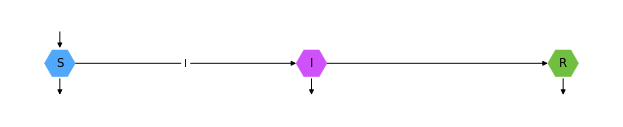

In [24]:
fig, ax = plt.subplots(1, figsize=(10, 2))
SIR_demo.draw_model(ax=ax)

In [25]:
SIR_demo.integrate(365, S=S0, I=I0, R=R0)

The impact of demographics is imediately visible:
- As new `Susceptibles` are added into the system, the total number of `Susceptibles` can increase as the epidemic wanes
- The death rate helps the `Infectious` population decrease quicker but remains non-zero thanks to the constant supply of `Susceptible` individuals
- The constant supply of new individuals can result in a second epidemic wave

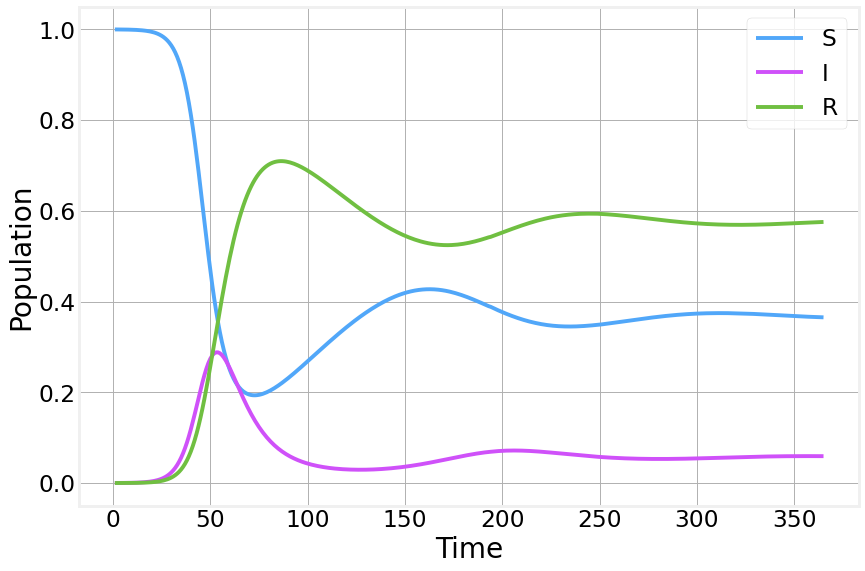

In [26]:
fig, ax = plt.subplots(1)
(SIR_demo.S/N).plot(ax=ax, label='S')
(SIR_demo.I/N).plot(ax=ax, label='I')
(SIR_demo.R/N).plot(ax=ax, label='R')

ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.legend()

We can make the effect obvious, by directly comparing this model with the original SIR model above:

Text(0, 0.5, 'Population')

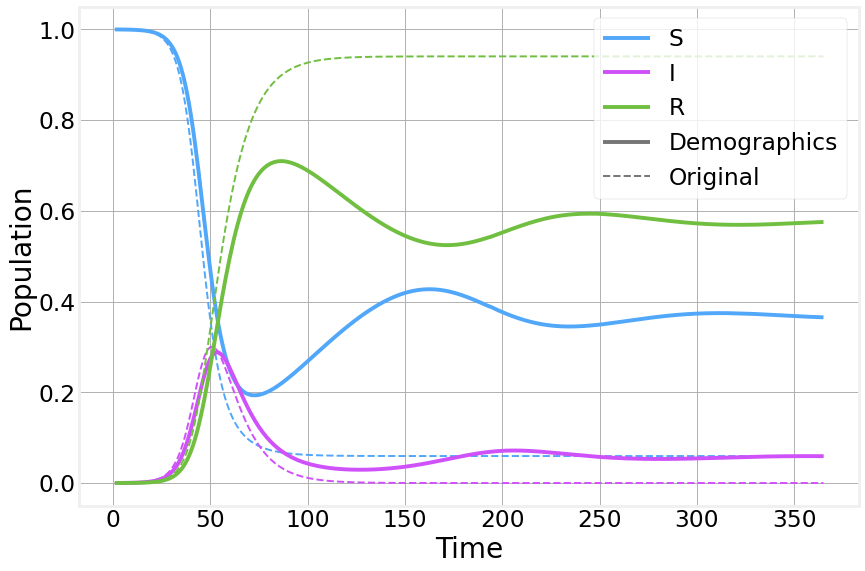

In [27]:
fig, ax = plt.subplots(1)
(SIR_demo.S/N).plot(ax=ax, label='S')
(SIR.S/N).plot(ax=ax, linestyle='--', color=colors[0], lw=2)  # Original SIR for comparison
(SIR_demo.I/N).plot(ax=ax, label='I')
(SIR.I/N).plot(ax=ax, linestyle='--', color=colors[1], lw=2)
(SIR_demo.R/N).plot(ax=ax, label='R')
(SIR.R/N).plot(ax=ax, linestyle='--', color=colors[2], lw=2)

# Create custom line objects for the legend
custom_lines = [Line2D([0], [0], color=colors[0], linestyle='-'),
                Line2D([0], [0], color=colors[1], linestyle='-'),
                Line2D([0], [0], color=colors[2], linestyle='-'),
                Line2D([0], [0], color="#757575", linestyle='-'),
                Line2D([0], [0], color="#757575", lw=2, linestyle='--'),
                ]

# Add the custom lines to the legend
ax.legend(custom_lines, ['S', 'I', 'R', 'Demographics', 'Original'], loc='upper right')
ax.set_xlabel('Time')
ax.set_ylabel('Population')

<center>
     <img src="data/D4Sci_logo_full.png" alt="Data For Science, Inc" align="center" border="0" width=300px> 
</center>